# Installing the necessary libraries and loading data into datasets

In [26]:
import shutil
shutil.unpack_archive('maternal-health-and-high-risk-pregnancy-dataset.zip', 'mh1')

import pandas as pd
df1= pd.read_excel('mh1/Book2.xlsx')

1. df1 is `binary classification`(IsAtRisk)
2. df2 is `multi-class classfication`(diet_adherence)

In [3]:
print(df1.columns, df1.loc[0].values, sep='\n')
df1 = df1.rename(columns = dict(zip(df1.columns, df1.loc[0].tolist())))

# Comprehensive mapping for our dataset columns to English equivalents
column_mapping = {
    'Name': 'Name',
    'Age': 'Age',
    'Gravida': 'Gravida',
    'TiTi Tika': 'TT_Vaccine',
    'গর্ভকাল': 'GestationalAge',          
    'ওজন': 'Weight',
    'উচ্চতা': 'Height',
    'রক্ত চাপ': 'BloodPressure',         
    'রক্তস্বল্পতা': 'Anemia',
    'জন্ডিস': 'Jaundice',
    'গর্ভস্হ শিশু অবস্থান': 'FetalPosition',
    'গর্ভস্হ শিশু নাড়াচাড়া': 'FetalMovement',
    'গর্ভস্হ শিশু হৃৎস্পন্দন': 'FetalHeartRate', 
    'প্রসাব পরিক্ষা এলবুমিন': 'Urine_Albumin',
    'প্রসাব পরিক্ষা সুগার': 'Urine_Sugar',  
    'VDRL': 'VDRL',
    'HRsAG': 'HBsAg',                     # Correcting typo from HRsAG to HBsAg
    'ঝুকিপূর্ণ গর্ভ': 'IsAtRisk'         # Target
}

# Let's apply the renaming to df1
df1 = df1.rename(columns=column_mapping)
df1 = df1.drop(0, axis=0)

Index(['ANCC REGISTER', 'Unnamed: 1', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4',
       'Unnamed: 5', 'Unnamed: 6', 'Unnamed: 7', 'Unnamed: 8', 'Unnamed: 9',
       'Unnamed: 10', 'Unnamed: 11', 'Unnamed: 12', 'Unnamed: 13',
       'Unnamed: 14', 'Unnamed: 15', 'Unnamed: 16', 'Unnamed: 17'],
      dtype='object')
['Name' 'Age' 'Gravida' 'TiTi Tika' 'গর্ভকাল' 'ওজন' 'উচ্চতা' 'রক্ত চাপ'
 'রক্তস্বল্পতা' 'জন্ডিস' 'গর্ভস্হ শিশু অবস্থান' 'গর্ভস্হ শিশু নাড়াচাড়া'
 'গর্ভস্হ শিশু হৃৎস্পন্দন' 'প্রসাব পরিক্ষা এলবুমিন' 'প্রসাব পরিক্ষা সুগার'
 'VDRL' 'HRsAG' 'ঝুকিপূর্ণ গর্ভ']


# Data clean-up and preprocessing

In [4]:
df1.isna().sum()

Name                0
Age                 0
Gravida             0
TT_Vaccine          0
GestationalAge      0
Weight              0
Height              0
BloodPressure       0
Anemia            875
Jaundice          986
FetalPosition       0
FetalMovement       0
FetalHeartRate      0
Urine_Albumin     864
Urine_Sugar         0
VDRL                0
HBsAg               0
IsAtRisk            0
dtype: int64

In [5]:
df1.head()

,Name,Age,Gravida,TT_Vaccine,GestationalAge,Weight,Height,BloodPressure,Anemia,Jaundice,FetalPosition,FetalMovement,FetalHeartRate,Urine_Albumin,Urine_Sugar,VDRL,HBsAg,IsAtRisk
1,Rituporna,18,1st,1st,38 week,50 kg,5.3'',100/60,NaN,NaN,Normal,Normal,140m,NaN,Yes,Negative,Negative,Yes
2,Moina,25,2nd,2nd,38 week,60 kg,5.2'',100/70,NaN,NaN,Normal,Normal,130m,NaN,Yes,Positive,Negative,No
3,Rabeya,20,1st,1st,30 week,55 kg,5.0'',100/60,NaN,NaN,Normal,Normal,120m,NaN,Yes,Negative,Negative,Yes
4,Shorna,22,1st,3rd,35 week,51 kg,5.4'',110/65,NaN,NaN,Normal,Normal,130m,NaN,Yes,Positive,Negative,Yes
5,Tania Akter,20,1st,2nd,30 week,53 kg,5.2'',100/55,NaN,NaN,Normal,Normal,125m,NaN,Yes,Negative,Negative,No


In [6]:
df1 = df1.drop(columns = ['Name'])
df1.head()

,Age,Gravida,TT_Vaccine,GestationalAge,Weight,Height,BloodPressure,Anemia,Jaundice,FetalPosition,FetalMovement,FetalHeartRate,Urine_Albumin,Urine_Sugar,VDRL,HBsAg,IsAtRisk
1,18,1st,1st,38 week,50 kg,5.3'',100/60,NaN,NaN,Normal,Normal,140m,NaN,Yes,Negative,Negative,Yes
2,25,2nd,2nd,38 week,60 kg,5.2'',100/70,NaN,NaN,Normal,Normal,130m,NaN,Yes,Positive,Negative,No
3,20,1st,1st,30 week,55 kg,5.0'',100/60,NaN,NaN,Normal,Normal,120m,NaN,Yes,Negative,Negative,Yes
4,22,1st,3rd,35 week,51 kg,5.4'',110/65,NaN,NaN,Normal,Normal,130m,NaN,Yes,Positive,Negative,Yes
5,20,1st,2nd,30 week,53 kg,5.2'',100/55,NaN,NaN,Normal,Normal,125m,NaN,Yes,Negative,Negative,No


# Using VIF score to calculate multi-colinearity amongst features

In [7]:
import pandas as pd
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

def vif(X):
    X = add_constant(X)
    vif_data = pd.DataFrame()
    vif_data["Feature"] = X.columns
    vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

    return vif_data

In [8]:
from sklearn.preprocessing import LabelEncoder

def preprocess_df(df):
    categorical_cols = df.select_dtypes(include=['object', 'category']).columns
    encoders = {col: LabelEncoder() for col in categorical_cols}

    for col in categorical_cols:
        df[col] = encoders[col].fit_transform(df[col])


In [9]:
X1= df1.drop('IsAtRisk', axis=1)

In [10]:
preprocess_df(X1)
vif1 = vif(X1)

/usr/local/lib/python3.12/dist-packages/statsmodels/regression/linear_model.py:1782: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.centered_tss


In [11]:
print(vif1)

           Feature         VIF
0            const  406.077967
1              Age    1.057535
2          Gravida    1.043657
3       TT_Vaccine    1.093314
4   GestationalAge    1.033766
5           Weight    1.093347
6           Height    1.017544
7    BloodPressure    1.088743
8           Anemia    1.007268
9         Jaundice    1.022425
10   FetalPosition    1.010621
11   FetalMovement         NaN
12  FetalHeartRate    1.002969
13   Urine_Albumin    1.009238
14     Urine_Sugar    1.080465
15            VDRL    1.101738
16           HBsAg    1.107589


In [12]:
df1 = df1.drop(columns = ['FetalMovement'])
df1.head()

,Age,Gravida,TT_Vaccine,GestationalAge,Weight,Height,BloodPressure,Anemia,Jaundice,FetalPosition,FetalHeartRate,Urine_Albumin,Urine_Sugar,VDRL,HBsAg,IsAtRisk
1,18,1st,1st,38 week,50 kg,5.3'',100/60,NaN,NaN,Normal,140m,NaN,Yes,Negative,Negative,Yes
2,25,2nd,2nd,38 week,60 kg,5.2'',100/70,NaN,NaN,Normal,130m,NaN,Yes,Positive,Negative,No
3,20,1st,1st,30 week,55 kg,5.0'',100/60,NaN,NaN,Normal,120m,NaN,Yes,Negative,Negative,Yes
4,22,1st,3rd,35 week,51 kg,5.4'',110/65,NaN,NaN,Normal,130m,NaN,Yes,Positive,Negative,Yes
5,20,1st,2nd,30 week,53 kg,5.2'',100/55,NaN,NaN,Normal,125m,NaN,Yes,Negative,Negative,No


In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

preprocess_df(df1)

# Feature Correlation heatmap plotting

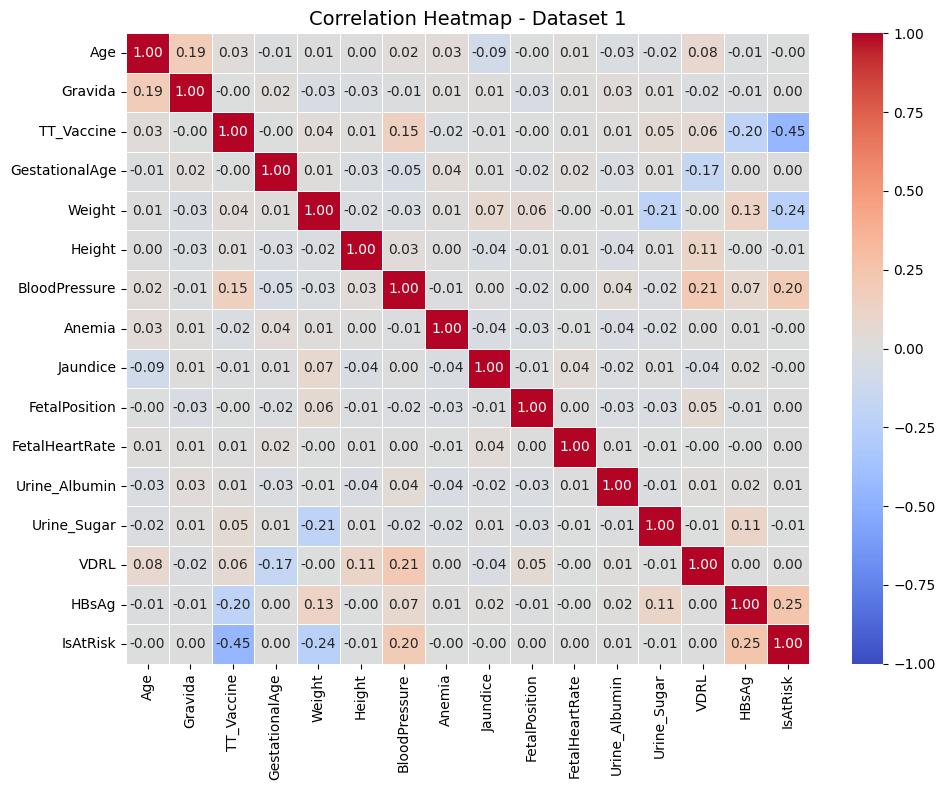

In [14]:
corr_df1 = df1.corr()

plt.figure(figsize=(10, 8))

sns.heatmap(
    corr_df1, 
    annot=True,         
    cmap="coolwarm",    
    fmt=".2f",           
    linewidths=0.5,     
    vmin=-1, vmax=1     
)

plt.title("Correlation Heatmap - Dataset 1", fontsize=14)
plt.tight_layout()
plt.show()

# Using DBSCAN algorithm to find outliers

In [15]:
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler as SS
temp = df1.copy()

scalers = [SS() for _ in range(1)]
ds = [temp]
scaled_datas = [scalers[i].fit_transform(ds[i]) for i in range(1)]

for i in range(1):
    dbscan = DBSCAN(eps=3.0, min_samples=20)
    clusters = dbscan.fit_predict(scaled_datas[i])
    ds[i]['Cluster'] = clusters
    print(len(ds[i][ds[i]["Cluster"] == -1]))

232


# Removing outliers on Dataset1 based on clustering

In [16]:
print(len(df1))
df1["Cluster"] = temp["Cluster"]
df1 = df1[df1["Cluster"] != -1]
print(len(df1))

998
766


In [17]:
print(df1["IsAtRisk"].value_counts())

IsAtRisk
1    520
0    246
Name: count, dtype: int64


In [18]:
df1 = df1.drop("Cluster", axis = 1)

In [19]:
df1.head()

,Age,Gravida,TT_Vaccine,GestationalAge,Weight,Height,BloodPressure,Anemia,Jaundice,FetalPosition,FetalHeartRate,Urine_Albumin,Urine_Sugar,VDRL,HBsAg,IsAtRisk
1,0,0,0,10,2,3,1,2,2,1,3,3,1,0,0,1
2,7,1,1,10,9,2,3,2,2,1,2,3,1,1,0,0
3,2,0,0,6,6,0,1,2,2,1,0,3,1,0,0,1
4,4,0,2,8,3,4,6,2,2,1,2,3,1,1,0,1
5,2,0,1,6,5,2,0,2,2,1,1,3,1,0,0,0


# Preparing dataset for train and evaluation purpose: 80:20 split

In [20]:
import joblib
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC

df1_train, df1_test = train_test_split(df1, test_size=0.2, random_state= 1087)

df1_test.to_csv('test1.csv', index=False)

# 5-fold Cross-validation on Dataset1 using Support Vector Classifier and GridSearchCV

In [21]:
X_train1 = df1_train.drop(columns=["IsAtRisk"])
y_train1 = df1_train["IsAtRisk"]

clf = Pipeline([('scaler', SS()), ('svm', SVC(probability=True, random_state=42))])

param_grid = {
    'svm__C': [50, 100, 200],
    'svm__kernel': ['linear', 'rbf'],
    'svm__gamma': ['scale', 'auto']  
}

grid_search = GridSearchCV(clf, param_grid, cv=5, n_jobs=-1, verbose=1)
grid_search.fit(X_train1, y_train1)

joblib.dump(grid_search.best_estimator_, 'model1.pkl')
print("Model1 saved to model1.pkl")

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Model1 saved to model1.pkl


In [22]:
print("Best Parameters:", grid_search.best_params_)
best_model = grid_search.best_estimator_
print("Support vectors:", best_model.named_steps['svm'].n_support_)

Best Parameters: {'svm__C': 50, 'svm__gamma': 'auto', 'svm__kernel': 'rbf'}
Support vectors: [105 161]
